In [4]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier, VotingClassifier
from catboost import CatBoostClassifier
from imblearn.over_sampling import SMOTE
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.metrics import accuracy_score
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.utils import to_categorical
from sklearn.metrics import accuracy_score,precision_score,recall_score,f1_score,mean_squared_error,roc_auc_score,roc_curve
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix
from sklearn.metrics import fbeta_score
from sklearn.metrics import cohen_kappa_score
from sklearn.metrics import matthews_corrcoef
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import AdaBoostClassifier
from sklearn.tree import DecisionTreeClassifier
import xgboost as xgb
from xgboost import XGBClassifier

In [5]:
%matplotlib inline

In [6]:
import pandas as pd

# Load the transaction and identity datasets
train_transaction = pd.read_csv('../data/ieee-fraud-detection/train_transaction.csv')
train_identity = pd.read_csv('../data/ieee-fraud-detection/train_identity.csv')

test_transaction = pd.read_csv('../data/ieee-fraud-detection/test_transaction.csv')
test_identity = pd.read_csv('../data/ieee-fraud-detection/test_identity.csv')

# Merge transaction and identity data (both for training and testing)
train = pd.merge(train_transaction, train_identity, how='left', on='TransactionID')
test = pd.merge(test_transaction, test_identity, how='left', on='TransactionID')


In [7]:
import pandas as pd

# Get the numeric columns from both train and test datasets
train_numeric_features = train.select_dtypes(include=['float64', 'int64']).columns
test_numeric_features = test.select_dtypes(include=['float64', 'int64']).columns

# Find the common numeric features between train and test
common_numeric_features = train_numeric_features.intersection(test_numeric_features)


# Identify numeric columns (forcing conversion)
train[common_numeric_features] = train[common_numeric_features].apply(pd.to_numeric, errors='coerce')
test[common_numeric_features] = test[common_numeric_features].apply(pd.to_numeric, errors='coerce')

# Apply Min-Max normalization only to common numeric columns
train[common_numeric_features] = train[common_numeric_features].apply(lambda x: (x - x.min()) / (x.max() - x.min()))
test[common_numeric_features] = test[common_numeric_features].apply(lambda x: (x - x.min()) / (x.max() - x.min()))

# Fill missing values with 0 (after conversion)
train = train.fillna(0)
test = test.fillna(0)


print("Preprocessing completed successfully.")


Preprocessing completed successfully.


In [8]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler


# Load dataset (assuming `train` contains labeled data)
# train = pd.read_csv("train_transaction.csv")

# Initialize LabelEncoder for target variable
labelencoder = LabelEncoder()

# Encode 'isFraud' (target variable)
train['isFraud'] = labelencoder.fit_transform(train['isFraud'])
print("Encoded classes:", labelencoder.classes_)  # Output encoded class labels



# Separate features (X) and target (Y)
X = train.drop(['isFraud', 'TransactionID'], axis=1)
Y = train['isFraud']  # Target

# Split into training and test sets with stratification
X_train, X_test, Y_train, Y_test = train_test_split(
    X, Y, train_size=0.8, test_size=0.2, random_state=42, stratify=Y
)

# Step 1: Identify categorical and numerical columns
categorical_columns = X_train.select_dtypes(include=['object']).columns.tolist()
numerical_columns = X_train.select_dtypes(exclude=['object']).columns.tolist()

# Step 2: Process categorical variables by ensuring all values are strings.
if len(categorical_columns) > 0:
    label_encoders = {}
    for col in categorical_columns:
        # Fill missing values with 'missing' and convert each value to string
        X_train[col] = X_train[col].apply(lambda x: 'missing' if pd.isnull(x) else str(x))
        # Optionally, you can check that all values are now strings:
        # print(f"Unique types in column {col}: {set(type(val) for val in X_train[col].unique())}")
        # Apply label encoding
        le = LabelEncoder()
        X_train[col] = le.fit_transform(X_train[col])
        label_encoders[col] = le

# Step 3: Scale numerical variables
if len(numerical_columns) > 0:
    scaler = StandardScaler()
    X_train[numerical_columns] = scaler.fit_transform(X_train[numerical_columns])

# Check the class distribution after splitting
print("Train class distribution:", np.bincount(Y_train))
print("Test class distribution:", np.bincount(Y_test))


Encoded classes: [0 1]
Train class distribution: [455902  16530]
Test class distribution: [113975   4133]


# Train test and split

In [9]:
X_train.shape

(472432, 432)

In [10]:
Y_test.shape

(118108,)

In [11]:
pd.Series(Y_train).value_counts()

isFraud
0    455902
1     16530
Name: count, dtype: int64

Calculating the correlation matrix for numeric features in the training set...
Correlation Matrix (preview):
                TransactionID   isFraud  TransactionDT  TransactionAmt  \
TransactionID        1.000000  0.014166       0.998280        0.012025   
isFraud              0.014166  1.000000       0.013103        0.011320   
TransactionDT        0.998280  0.013103       1.000000        0.011920   
TransactionAmt       0.012025  0.011320       0.011920        1.000000   
card1                0.010122 -0.013640       0.010625       -0.005725   

                   card1     card2     card3     card5     addr1     addr2  \
TransactionID   0.010122 -0.018313 -0.018253 -0.025731 -0.003958 -0.001200   
isFraud        -0.013640  0.001614  0.150361 -0.034063 -0.080784 -0.161130   
TransactionDT   0.010625 -0.017606 -0.019531 -0.025997 -0.002092  0.001295   
TransactionAmt -0.005725  0.012587 -0.107548  0.000229  0.065895  0.138196   
card1           1.000000  0.011532  0.002961 -0.090089  

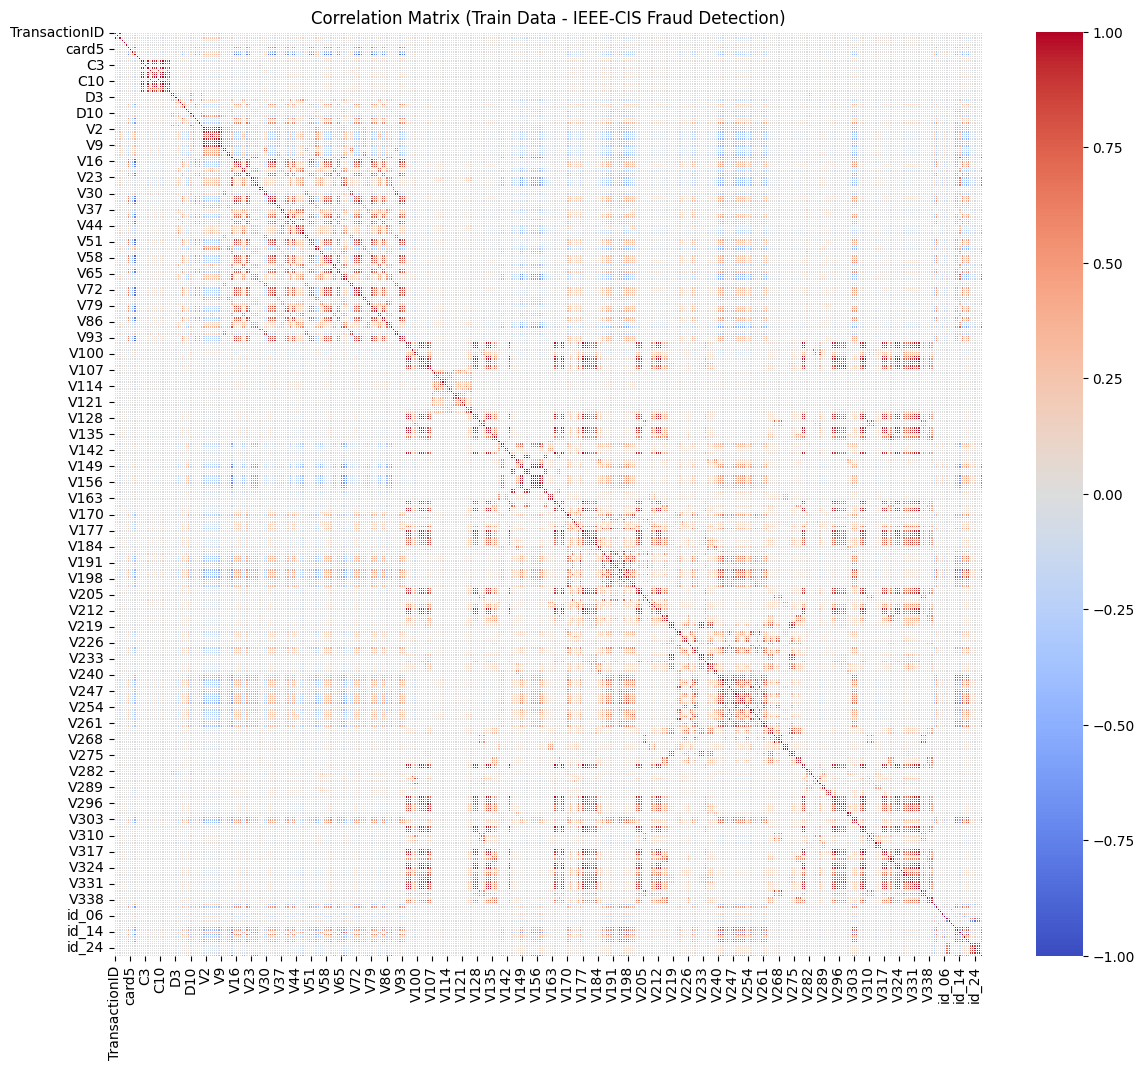

In [12]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# Select only numeric columns for correlation analysis
numeric_features = train.select_dtypes(include=[np.number]).columns

# Compute the correlation matrix on the training set
print("Calculating the correlation matrix for numeric features in the training set...")
correlation_matrix = train[numeric_features].corr()

# Display the first few rows of the correlation matrix
print("Correlation Matrix (preview):")
print(correlation_matrix.head())

# Plot the heatmap
plt.figure(figsize=(14, 12))
sns.heatmap(correlation_matrix, annot=False, cmap='coolwarm', linewidths=0.5, vmin=-1, vmax=1)
plt.title('Correlation Matrix (Train Data - IEEE-CIS Fraud Detection)')
plt.show()


Correlation with the target variable:
isFraud    1.000000
V257       0.281349
V201       0.268686
V246       0.266292
V200       0.262079
             ...   
V69       -0.102396
V90       -0.102635
V29       -0.102738
id_01     -0.144516
addr2     -0.161130
Name: isFraud, Length: 403, dtype: float64


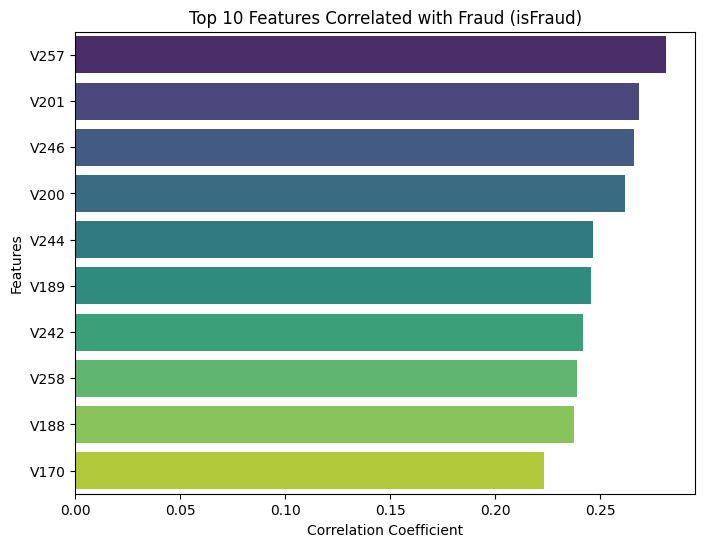

In [13]:
import seaborn as sns
import matplotlib.pyplot as plt

# Ensure the target column exists
target_column = 'isFraud'  # IEEE-CIS fraud detection target

if target_column in train.columns:
    # Compute correlation matrix only for numeric features
    numeric_features = train.select_dtypes(include=['number']).columns
    correlation_matrix = train[numeric_features].corr()

    # Get correlation with the target variable
    target_corr = correlation_matrix[target_column].sort_values(ascending=False)
    print("Correlation with the target variable:")
    print(target_corr)

    # Visualize the top correlated features (excluding the target itself)
    top_features = target_corr[1:11]  # Exclude correlation with itself
    plt.figure(figsize=(8, 6))
    sns.barplot(x=top_features.values, y=top_features.index, hue=top_features.index, dodge=False, palette='viridis', legend=False)
    plt.title('Top 10 Features Correlated with Fraud (isFraud)')
    plt.xlabel('Correlation Coefficient')
    plt.ylabel('Features')
    plt.show()
else:
    print(f"The '{target_column}' column does not exist in the train dataset.")


In [14]:
import numpy as np
import pandas as pd

# Combine train and test sets temporarily
X_full = pd.concat([X_train, X_test], axis=0)

# Keep only numeric columns for correlation calculation
X_numeric = X_full.select_dtypes(include=np.number)

# Compute correlation matrix
corr_matrix = X_numeric.corr()

# Check the range of correlation values
max_corr = corr_matrix.where(~corr_matrix.isna()).max().max()
min_corr = corr_matrix.where(~corr_matrix.isna()).min().min()
print(f"Correlation range: min={min_corr:.2f}, max={max_corr:.2f}")

# Lower the threshold for moderate correlations
threshold = 0.9
strong_corr_pairs = []

# Find pairs of strongly correlated features
for i in range(len(corr_matrix.columns)):
    for j in range(i):
        if abs(corr_matrix.iloc[i, j]) > threshold:
            strong_corr_pairs.append((corr_matrix.columns[i], corr_matrix.columns[j], corr_matrix.iloc[i, j]))

print(f"Strongly correlated features (>|{threshold}|):")
for pair in strong_corr_pairs:
    print(f"{pair[0]} and {pair[1]} : {pair[2]:.2f}")

# Extract upper triangle
upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))

# Identify columns to drop with correlation > threshold
to_drop = [column for column in upper.columns if any(upper[column] > threshold)]
print(f"⚠️ Highly correlated features to drop (>|{threshold}|): {len(to_drop)}")
print(to_drop)

# Drop those columns from original train and test sets
X_train_reduced = X_train.drop(columns=to_drop)
X_test_reduced = X_test.drop(columns=to_drop)

print(f"✅ Reduced training features: {X_train_reduced.shape[1]} (from {X_train.shape[1]})")
print(f"✅ Reduced test features: {X_test_reduced.shape[1]} (same columns kept)")


Correlation range: min=-0.92, max=1.00
Strongly correlated features (>|0.9|):
C2 and C1 : 0.99
C4 and C1 : 0.97
C4 and C2 : 0.97
C6 and C1 : 0.98
C6 and C2 : 0.97
C6 and C4 : 0.96
C7 and C1 : 0.92
C7 and C2 : 0.94
C8 and C1 : 0.97
C8 and C2 : 0.98
C8 and C4 : 0.96
C8 and C6 : 0.92
C8 and C7 : 0.98
C9 and C5 : 0.93
C10 and C1 : 0.96
C10 and C2 : 0.97
C10 and C4 : 0.95
C10 and C6 : 0.91
C10 and C7 : 0.98
C10 and C8 : 1.00
C11 and C1 : 1.00
C11 and C2 : 0.99
C11 and C4 : 0.97
C11 and C6 : 0.99
C11 and C7 : 0.91
C11 and C8 : 0.96
C11 and C10 : 0.96
C12 and C1 : 0.93
C12 and C2 : 0.94
C12 and C7 : 1.00
C12 and C8 : 0.98
C12 and C10 : 0.98
C12 and C11 : 0.91
C14 and C1 : 0.95
C14 and C2 : 0.94
C14 and C4 : 0.91
C14 and C6 : 0.98
C14 and C11 : 0.96
D2 and D1 : 0.97
V2 and V1 : 0.91
V3 and V2 : 0.97
V5 and V4 : 0.97
V6 and V1 : 0.91
V6 and V2 : 0.96
V6 and V3 : 0.93
V7 and V2 : 0.94
V7 and V3 : 0.93
V7 and V6 : 0.97
V8 and V1 : 0.93
V8 and V2 : 0.98
V8 and V3 : 0.94
V8 and V6 : 0.97
V8 and V7 

In [49]:
X = pd.concat([pd.DataFrame(X_train_reduced), pd.DataFrame(X_test_reduced)], axis=0).reset_index(drop=True)
# 3. Optional: check the combined shape and top columns
print("✅ Combined feature matrix shape:", X.shape)
print("Feature names:", X.columns[:229].tolist())

✅ Combined feature matrix shape: (590540, 229)
Feature names: ['TransactionDT', 'TransactionAmt', 'ProductCD', 'card1', 'card2', 'card3', 'card4', 'card5', 'card6', 'addr1', 'addr2', 'dist1', 'dist2', 'P_emaildomain', 'R_emaildomain', 'C1', 'C3', 'C5', 'C13', 'D1', 'D3', 'D4', 'D5', 'D6', 'D7', 'D8', 'D9', 'D10', 'D11', 'D12', 'D13', 'D14', 'D15', 'M1', 'M2', 'M3', 'M4', 'M5', 'M6', 'M7', 'M8', 'M9', 'V1', 'V4', 'V10', 'V12', 'V14', 'V15', 'V17', 'V19', 'V23', 'V25', 'V27', 'V29', 'V35', 'V37', 'V39', 'V41', 'V42', 'V44', 'V48', 'V53', 'V55', 'V56', 'V59', 'V61', 'V66', 'V68', 'V75', 'V77', 'V78', 'V80', 'V82', 'V86', 'V88', 'V89', 'V95', 'V98', 'V99', 'V100', 'V104', 'V107', 'V108', 'V109', 'V110', 'V111', 'V112', 'V114', 'V115', 'V116', 'V117', 'V118', 'V120', 'V121', 'V122', 'V123', 'V124', 'V125', 'V129', 'V130', 'V131', 'V135', 'V136', 'V138', 'V139', 'V141', 'V142', 'V144', 'V146', 'V148', 'V161', 'V162', 'V165', 'V166', 'V169', 'V170', 'V171', 'V172', 'V173', 'V174', 'V175', 'V1

In [50]:
#smote = SMOTE()
print(type(Y))
print(Y.dtype)
print(np.unique(Y))
pd.Series(Y_train).value_counts()

<class 'pandas.core.series.Series'>
int64
[0 1]


isFraud
0    455902
1     16530
Name: count, dtype: int64

# Outliers removal

In [51]:
import numpy as np
import pandas as pd
from scipy import stats
from scipy.stats import shapiro
from sklearn.ensemble import IsolationForest


def check_outliers(X, Y, threshold=3, iqr_factor=1.5):
    """
    Check if outliers exist in the dataset (X and Y) using Z-score or IQR.
    Returns True if outliers are detected in either X or Y, False otherwise.
    """
    if not isinstance(Y, pd.Series):
        Y = pd.Series(Y, index=X.index)

    # Separate normal and fraudulent transactions
    X_normal = X[Y == 0].select_dtypes(include=['number'])  # Select numeric columns
    Y_normal = Y[Y == 0]
    
    # Ensure Y is a pandas Series
    if not isinstance(Y, pd.Series):
        Y = pd.Series(Y, index=X.index)
    
    # Filter only numeric columns for X
    X_numeric = X_normal.select_dtypes(include=['number'])
    
    # Calculate Z-scores for X and Y
    z_scores_X = np.abs(stats.zscore(X_numeric))
    z_scores_Y = np.abs(stats.zscore(Y_normal))
    
    outliers_zscore_X = (z_scores_X > threshold).any().any()
    outliers_zscore_Y = (z_scores_Y > threshold).any()
    
    # Calculate IQR for X and Y
    Q1_X = X_numeric.quantile(0.25)
    Q3_X = X_numeric.quantile(0.75)
    IQR_X = Q3_X - Q1_X
    
    Q1_Y = Y.quantile(0.25)
    Q3_Y = Y.quantile(0.75)
    IQR_Y = Q3_Y - Q1_Y
    
    outliers_iqr_X = ((X_numeric < (Q1_X - iqr_factor * IQR_X)) | (X_numeric > (Q3_X + iqr_factor * IQR_X))).any().any()
    outliers_iqr_Y = ((Y_normal < (Q1_Y - iqr_factor * IQR_Y)) | (Y_normal > (Q3_Y + iqr_factor * IQR_Y))).any()
    
    return outliers_zscore_X or outliers_zscore_Y or outliers_iqr_X or outliers_iqr_Y
    
def remove_outliers(X, Y, method="auto", threshold=3, iqr_factor=1.5):
    """
    Removes outliers from normal transactions only.
    """

    if not isinstance(Y, pd.Series):
        Y = pd.Series(Y, index=X.index)

    # Separate normal and fraudulent transactions
    X_normal = X[Y == 0].select_dtypes(include=['number'])  # Select numeric columns
    Y_normal = Y[Y == 0]
    X_fraud = X[Y == 1]
    Y_fraud = Y[Y == 1]

    # Outlier removal
    if method == "auto":
        print("Automatically selecting outlier removal method...")
        if X_normal.std().mean() < threshold:
            print("Using Z-score for outlier removal...")
            X_normal_cleaned, Y_normal_cleaned = remove_outliers_using_zscore(X_normal, Y_normal, threshold)
        else:
            print("Using IQR for outlier removal...")
            X_normal_cleaned = remove_outliers_using_iqr(X_normal, iqr_factor)
            Y_normal_cleaned = Y_normal.loc[X_normal_cleaned.index]

    elif method == "zscore":
        print("Using Z-score for outlier removal...")
        X_normal_cleaned, Y_normal_cleaned = remove_outliers_using_zscore(X_normal, Y_normal, threshold)

    elif method == "iqr":
        print("Using IQR for outlier removal...")
        X_normal_cleaned = remove_outliers_using_iqr(X_normal, iqr_factor)
        Y_normal_cleaned = Y_normal.loc[X_normal_cleaned.index]

    elif method == "isolation_forest":
        print("Using Isolation Forest for outlier removal...")
        X_normal_cleaned, Y_normal_cleaned = remove_outliers_using_if(X_normal, Y_normal)

    # Reunify data
    X_cleaned = pd.concat([X_normal_cleaned, X_fraud], axis=0).sort_index()
    Y_cleaned = pd.concat([Y_normal_cleaned, Y_fraud], axis=0).sort_index()

    return X_cleaned, Y_cleaned

def remove_outliers_using_zscore(X, Y, threshold):
    """
    Removes outliers using the Z-score method.
    """
    z_scores = np.abs(stats.zscore(X))
    X_filtered = X[(z_scores < threshold).all(axis=1)]
    Y_filtered = Y.loc[X_filtered.index]
    return X_filtered, Y_filtered

def remove_outliers_using_iqr(X, iqr_factor=1.5):
    """
    Removes outliers using the IQR method.
    """
    Q1 = X.quantile(0.25)
    Q3 = X.quantile(0.75)
    IQR = Q3 - Q1
    return X[~((X < (Q1 - iqr_factor * IQR)) | (X > (Q3 + iqr_factor * IQR))).any(axis=1)].copy()

def remove_outliers_using_if(X, Y, contamination=0.05):
    """
    Removes outliers using Isolation Forest.
    """
    model = IsolationForest(contamination=contamination, random_state=42)
    preds = model.fit_predict(X)
    X_filtered = X[preds != -1]  # IsolationForest marks outliers as -1
    Y_filtered = Y.loc[X_filtered.index]
    return X_filtered, Y_filtered

# Example usage:
# X_cleaned, Y_cleaned = remove_outliers(X, Y, method="auto")

In [52]:
# Assuming X is your DataFrame (features) and Y is your Series (target)
outliers_exist = check_outliers(X, Y)
print(f"Outliers detected: {outliers_exist}")

# Step 2: Remove outliers if they exist
if outliers_exist:
    X_filtered, y_filtered = remove_outliers(X, Y, method="auto", threshold=3, iqr_factor=1.5)
    print("Outliers removed.")
else:
    print("No outliers detected. Data is clean.")

print("Cleaned Features (X):")
print(X_filtered)
print("\nCleaned Target (Y):")
print(y_filtered)

Outliers detected: True
Automatically selecting outlier removal method...
Using IQR for outlier removal...
Outliers removed.
Cleaned Features (X):
        TransactionDT  TransactionAmt     card1     card2     card3     card5  \
1           -0.079104       -0.435353 -0.408558 -0.084812 -0.262833  0.606255   
38           0.716388       -0.157731  0.930914 -1.348651 -0.262833  0.653968   
53           0.141692       -0.333808  0.255773 -0.898174 -0.262833  0.653968   
55           1.276506       -0.335880 -0.578057 -1.548863 -0.262833 -0.777427   
69          -1.221603       -0.110087  1.378424  0.822399 -0.262833  0.653968   
...               ...             ...       ...       ...       ...       ...   
590361       0.330169        0.001558  0.638997  0.608000  0.381679  0.014599   
590364       0.555025        0.000775  0.108301  0.780000  0.381679  0.919708   
590368       0.823893        0.002746  0.523799  0.520000  0.381679  0.481752   
590372       0.093698        0.002607  0.39

In [53]:
# Check class distribution before SMOTE
#print("Unique classes in y_filtered:", np.unique(y_filtered))
#print("Class distribution in y_filtered:\n", pd.Series(y_filtered).value_counts())
#print(X_filtered.shape)
#print(y_filtered.shape)

#X_filtered = X_filtered.reset_index(drop=True)
#y_filtered = y_filtered.reset_index(drop=True)
#print("Class distribution in y_filtered:\n", pd.Series(y_filtered).value_counts())

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X_filtered, y_filtered, test_size=0.2, random_state=42, stratify=y_filtered)

print("Unique classes in y_train after split:", np.unique(y_train))
print("Class distribution in y_train after split:\n", pd.Series(y_train).value_counts())


Unique classes in y_train after split: [0 1]
Class distribution in y_train after split:
 isFraud
0    24322
1    16530
Name: count, dtype: int64


# SMOTE resampling

In [54]:
import pandas as pd
import numpy as np
from collections import Counter
from imblearn.over_sampling import SMOTE, SMOTENC, ADASYN
from imblearn.combine import SMOTEENN
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
# Check the data types of each column
#print(X_train.dtypes)

print("y_train Before resampling:", Counter(y_train))

# Identify categorical columns
categorical_columns = X_train.select_dtypes(include=['object']).columns

#print(categorical_columns)

# Apply OneHotEncoder only to categorical columns
column_transformer = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(), categorical_columns)
    ],
    remainder='passthrough'  # Leave other numerical columns unchanged
)
# Convertir toutes les colonnes catégorielles en chaînes de caractères
X_train[categorical_columns] = X_train[categorical_columns].astype(str)


# Apply transformation to X_train
X_train_encoded = column_transformer.fit_transform(X_train)
# Initialize ADASYN
smote = SMOTE(random_state=42, sampling_strategy=0.8)
# "sampling_strategy" can be:
# - "auto": oversample the minority class until its count equals that of the majority class.
# - a float in (0, 1]: the desired ratio of minority to majority samples.
# - a dict: explicit numbers for each class.

# Apply ADASYN to resample the training data
X_resampled, y_resampled = smote.fit_resample(X_train_encoded, y_train)

# Step 8: Check class distribution after resampling
print("After resampling:", Counter(y_resampled))
# Create a new DataFrame with the resampled data
data_resampled = pd.concat([pd.DataFrame(X_resampled), pd.Series(y_resampled, name='isFraud')], axis=1)

y_train Before resampling: Counter({0: 24322, 1: 16530})
After resampling: Counter({0: 24322, 1: 19457})


In [55]:
X_train, X_test, y_train, y_test = train_test_split(X_resampled, y_resampled, train_size = 0.8, test_size = 0.2, random_state = 42,stratify = y_resampled)

# Feature importance

In [56]:
# Initialize models
models = {
    "Decision Tree": DecisionTreeClassifier(criterion='entropy', random_state=42),
    "Random Forest": RandomForestClassifier(random_state=42),
    "Extra Trees": ExtraTreesClassifier(random_state=42),
    "XGBoost": XGBClassifier(n_estimators=50),
    #"CataBoost": CatBoostClassifier(random_state=42),
    "AdaBoost": AdaBoostClassifier(DecisionTreeClassifier(max_depth=1), n_estimators=50)
}

In [57]:
feature_importances = np.zeros(X_resampled.shape[1])
for name, model in models.items():
    # Train the model
    model.fit(X_resampled,y_resampled)
    if hasattr(model, "feature_importances_"):
        #feature_importances = model.feature_importances_
        feature_importances += model.feature_importances_
        print(f"{name} Feature Importances:\n{model.feature_importances_}")
    else:
        print(f"{name} does not have feature_importances_ attribute.")

Decision Tree Feature Importances:
[0. 0. 0. ... 0. 0. 0.]
Random Forest Feature Importances:
[4.60243498e-05 0.00000000e+00 0.00000000e+00 ... 0.00000000e+00
 0.00000000e+00 0.00000000e+00]
Extra Trees Feature Importances:
[0.00067607 0.00054792 0.         ... 0.         0.         0.        ]
XGBoost Feature Importances:
[0. 0. 0. ... 0. 0. 0.]
AdaBoost Feature Importances:
[0. 0. 0. ... 0. 0. 0.]


In [58]:
print(len(models))

5


In [59]:
avg_feature = feature_importances/len(models)

In [60]:
import pandas as pd
import numpy as np
from scipy.sparse import issparse

# --- Feature Selection based on Importance ---

# 1. Sort features by their average importance scores
print("Features sorted by their score:")
sorted_features = sorted(zip(avg_feature, range(len(avg_feature))), reverse=True)
sorted_scores, sorted_indices = zip(*sorted_features)

# 2. Compute cumulative importance
cumulative_importance = np.cumsum(sorted_scores)

# 3. Get index up to 90% cumulative importance
if np.any(cumulative_importance >= 0.9):
    index = np.where(cumulative_importance >= 0.9)[0][0]
else:
    index = len(sorted_indices) - 1  # Take all features if 0.9 not reached

important_indices = sorted_indices[:index + 1]
print(f"Selected {len(important_indices)} important features (90% importance).")

# 4. Convert X_resampled to DataFrame with default column names
if issparse(X_resampled):
    X_resampled_df = pd.DataFrame(X_resampled.toarray(), columns=[f"f{i}" for i in range(X_resampled.shape[1])])
elif isinstance(X_resampled, np.ndarray):
    X_resampled_df = pd.DataFrame(X_resampled, columns=[f"f{i}" for i in range(X_resampled.shape[1])])
else:
    X_resampled_df = X_resampled.copy()
    if X_resampled_df.shape[1] != len(avg_feature):
        X_resampled_df.columns = [f"f{i}" for i in range(X_resampled_df.shape[1])]

# 5. Select only the important feature columns
important_columns = [f"f{i}" for i in important_indices]
X_selected = X_resampled_df[important_columns].to_numpy()

# 6. Confirm
print("✅ Feature selection completed successfully.")
print("X_selected shape:", X_selected.shape)
print("Top 10 important features indices:", important_indices[:10], "...")
print("Top 10 important features scores:", sorted_scores[:10], "...")

Features sorted by their score:
Selected 30 important features (90% importance).
✅ Feature selection completed successfully.
X_selected shape: (43779, 30)
Top 10 important features indices: (274, 10, 1210, 288, 432, 280, 715, 570, 28, 695) ...
Top 10 important features scores: (np.float64(0.21198358780177892), np.float64(0.21073786914529152), np.float64(0.2077277951452945), np.float64(0.016263017422456165), np.float64(0.015293295048994357), np.float64(0.013090018564734093), np.float64(0.012978931879234499), np.float64(0.012900009171629551), np.float64(0.012613998022308098), np.float64(0.012538522635470378)) ...


In [44]:
len(sorted_features)

1418

In [62]:
X_train, X_test, y_train, y_test = train_test_split(X_selected, y_resampled, train_size=0.8, test_size=0.2, random_state=42, stratify=y_resampled)

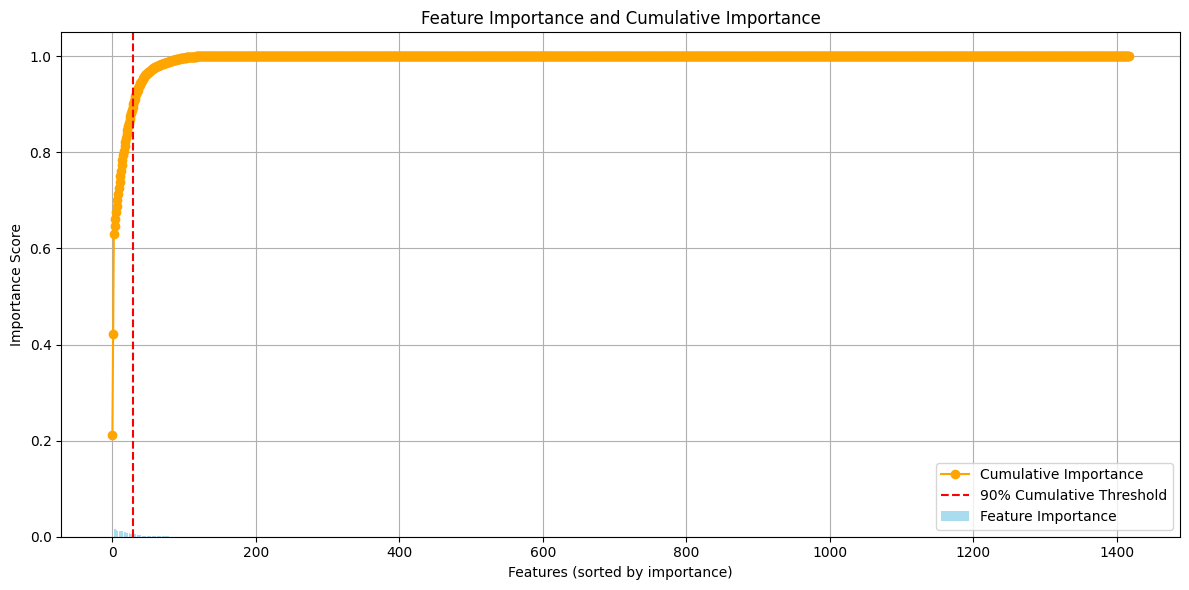

In [67]:
import matplotlib.pyplot as plt

# Plot sorted feature importances and cumulative importance
plt.figure(figsize=(12,6))

# Bar plot for feature importances
plt.bar(range(len(sorted_scores)), sorted_scores, alpha=0.7, label='Feature Importance', color='skyblue')

# Cumulative importance line
plt.plot(range(len(sorted_scores)), cumulative_importance, color='orange', marker='o', label='Cumulative Importance')

# Highlight features selected for 90% importance
plt.axvline(x=index, color='red', linestyle='--', label='90% Cumulative Threshold')

plt.title('Feature Importance and Cumulative Importance')
plt.xlabel('Features (sorted by importance)')
plt.ylabel('Importance Score')
plt.legend()
plt.grid(True)
plt.tight_layout()

# Save figure
plt.savefig('feature_importance_plot.png', dpi=300)
plt.show()


# GridSearch application

In [68]:
from sklearn.model_selection import GridSearchCV
# Define Parameter Grids for GridSearchCV
param_grid_dt = {'max_depth': [10, 20, None], 'min_samples_split': [2, 5, 10]}
param_grid_rf = {'n_estimators': [100, 200], 'max_depth': [10, 20, None]}
param_grid_et = {'n_estimators': [100, 200], 'max_depth': [10, 20, None]}
param_grid_xgb = {'n_estimators': [100, 200], 'learning_rate': [0.01, 0.1, 0.2]}
param_grid_ada = {'n_estimators': [50, 100, 200], 'learning_rate': [0.01, 0.1, 1]}

In [69]:
import warnings
warnings.filterwarnings("ignore", category=UserWarning, module='xgboost')
# Train and Tune Models
def grid_search(model, param_grid, name):
    grid = GridSearchCV(model, param_grid, cv=5, scoring=['accuracy', 'f1', 'roc_auc'], refit='accuracy', n_jobs=-1)
    grid.fit(X_train, y_train)
    print(f"Best parameters for {name}: {grid.best_params_}")
    return grid.best_estimator_


best_dt = grid_search(DecisionTreeClassifier(criterion='entropy', random_state=42), param_grid_dt, "Decision Tree")
best_rf = grid_search(RandomForestClassifier(random_state=42), param_grid_rf, "Random Forest")
best_et = grid_search(ExtraTreesClassifier(random_state=42), param_grid_et, "Extra Trees")
best_xgb = grid_search(XGBClassifier(n_estimators=50, eval_metric='logloss'), param_grid_xgb, "XGBoost")
best_ada = grid_search(AdaBoostClassifier(DecisionTreeClassifier(max_depth=1), n_estimators=50), param_grid_ada, "AdaBoost")

Best parameters for Decision Tree: {'max_depth': 10, 'min_samples_split': 2}
Best parameters for Random Forest: {'max_depth': 10, 'n_estimators': 100}
Best parameters for Extra Trees: {'max_depth': 10, 'n_estimators': 100}
Best parameters for XGBoost: {'learning_rate': 0.01, 'n_estimators': 100}
Best parameters for AdaBoost: {'learning_rate': 0.01, 'n_estimators': 50}


# Voting for best results

In [70]:
import numpy as np
from sklearn.model_selection import StratifiedKFold, GridSearchCV
from sklearn.ensemble import VotingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense
from tensorflow.keras.utils import to_categorical

# Step 1: Store Predictions for Meta-Model
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
meta_features_train = np.zeros((X_train.shape[0], 5))  # 5 models
meta_features_test = np.zeros((X_test.shape[0], 5))

# Base models
base_models = [
    ('dt', best_dt),
    ('rf', best_rf),
    ('et', best_et),
    ('xgb', best_xgb),
    ('ada', best_ada)
]
y_train = y_train.to_numpy()  # Convert to NumPy array

for train_idx, val_idx in skf.split(X_train, y_train):
    X_tr, X_val = X_train[train_idx], X_train[val_idx]
    #y_tr, y_val = y_train[train_idx], y_train[val_idx]
    y_tr, y_val = y_train[train_idx], y_train[val_idx]


    
    # Train base models and store predictions for meta-model
    for i, (name, model) in enumerate(base_models):
        model.fit(X_tr, y_tr)
        meta_features_train[val_idx, i] = model.predict_proba(X_val)[:, 1]  # Use probabilities

# Fit final models on full training data to predict test meta-features
for i, (name, model) in enumerate(base_models):
    model.fit(X_train, y_train)
    meta_features_test[:, i] = model.predict_proba(X_test)[:, 1]

# Step 2: Define and Tune Voting Classifier with GridSearchCV
voting_clf = VotingClassifier(estimators=base_models, voting='soft')

# Tune Voting Weights Using GridSearchCV
param_grid_voting = {
    'weights': [
        (1, 1, 1, 1, 1),
        (1, 2, 2, 3, 1),
        (2, 1, 1, 1, 2),
        (3, 2, 1, 2, 1),
        (1, 1, 2, 2, 3)
    ]
}

grid_voting = GridSearchCV(voting_clf, param_grid_voting, cv=5, scoring='accuracy', n_jobs=-1)
grid_voting.fit(meta_features_train, y_train)  # Use meta-features for fitting

# Best Voting Classifier with Optimized Weights
best_voting = grid_voting.best_estimator_
print(f"Best Voting Weights: {grid_voting.best_params_}")


Best Voting Weights: {'weights': (1, 1, 1, 1, 1)}


# Second Stage : LSTM predictions

In [71]:
from tensorflow.keras.optimizers import Adam
# Step 3: LSTM Meta-Learner on top of Voting Classifier Predictions
best_voting.fit(X_train, y_train)

# Get Predictions from Voting Classifier (probabilities)
y_pred_voting_train = best_voting.predict_proba(X_train)[:, 1]  # Probabilities of class 1
y_pred_voting_test = best_voting.predict_proba(X_test)[:, 1]  # Probabilities of class 1

# Reshape for LSTM (required shape: [samples, time_steps, features])
X_train_lstm = y_pred_voting_train.reshape(-1, 1, 1)  # Shape (samples, 1, 1)
X_test_lstm = y_pred_voting_test.reshape(-1, 1, 1)  # Shape (samples, 1, 1)

# Convert Labels to Categorical
y_train_cat = to_categorical(y_train, num_classes=2)
y_test_cat = to_categorical(y_test, num_classes=2)

# Check the shape of the labels
print("Shape of y_train_cat:", y_train_cat.shape)
print("Shape of y_test_cat:", y_test_cat.shape)

Shape of y_train_cat: (35023, 2)
Shape of y_test_cat: (8756, 2)


# Final performance results

## Add autoencoders

In [74]:
from tensorflow.keras.layers import Input, Dense, Dropout, BatchNormalization
from tensorflow.keras.models import Model, Sequential
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.regularizers import l2
from tensorflow.keras.utils import to_categorical
from sklearn.metrics import accuracy_score

# Define the Autoencoder
input_shape = (X_train_lstm.shape[1],)  # Adjust input shape based on your data
input_layer = Input(shape=input_shape)

# Encoder
encoded = Dense(256, activation='relu')(input_layer)
encoded = BatchNormalization()(encoded)
encoded = Dropout(0.3)(encoded)
encoded = Dense(128, activation='relu')(encoded)
encoded = BatchNormalization()(encoded)
encoded = Dropout(0.3)(encoded)
encoded = Dense(64, activation='relu')(encoded)

# Decoder
decoded = Dense(128, activation='relu')(encoded)
decoded = BatchNormalization()(decoded)
decoded = Dropout(0.3)(decoded)
decoded = Dense(256, activation='relu')(decoded)
decoded = BatchNormalization()(decoded)
decoded = Dropout(0.3)(decoded)
decoded = Dense(input_shape[0], activation='sigmoid')(decoded)

autoencoder = Model(input_layer, decoded)
autoencoder.compile(optimizer=Adam(learning_rate=0.001), loss='mse')

# Train the Autoencoder
autoencoder.fit(X_train_lstm, X_train_lstm,
                epochs=50,
                batch_size=32,
                validation_data=(X_test_lstm, X_test_lstm))

# Print model summary
autoencoder.summary()

# Step 3: Create an Encoder Model for Feature Extraction
encoder = Model(input_layer, encoded)

# Step 4: LSTM Meta-Learner on top of the encoded features
# (Assuming best_voting is a previously trained ensemble model)
y_pred_voting_train = best_voting.predict_proba(X_train)[:, 1]  # Probabilities for class 1
y_pred_voting_test = best_voting.predict_proba(X_test)[:, 1]  # Probabilities for class 1

# Convert Labels to Categorical
y_train_cat = to_categorical(y_train, num_classes=2)
y_test_cat = to_categorical(y_test, num_classes=2)

# Get the encoded representations (compressed features) for both train and test data
X_train_encoded = encoder.predict(X_train_lstm)
X_test_encoded = encoder.predict(X_test_lstm)

# Check the shape of the categorical labels
print("Shape of y_train_cat:", y_train_cat.shape)
print("Shape of y_test_cat:", y_test_cat.shape)

Epoch 1/50
1095/1095 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - loss: 0.0042 - val_loss: 0.0025
Epoch 2/50
1095/1095 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 0.0017 - val_loss: 0.0011
Epoch 3/50
1095/1095 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 0.0011 - val_loss: 9.0226e-04
Epoch 4/50
1095/1095 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 9.5796e-04 - val_loss: 5.3404e-04
Epoch 5/50
1095/1095 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 8.9083e-04 - val_loss: 2.0013e-04
Epoch 6/50
1095/1095 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 7.4683e-04 - val_loss: 1.3972e-04
Epoch 7/50
1095/1095 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 7.1672e-04 - val_loss: 9.8147e-05
Epoch 8/50
1095/1095 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 6.9122e-04 - val_loss: 4.2063e-05
Epoch 9/50
1095/1095 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 8.1065e-04 - val_loss: 1.2783e-04
Epoch 10/50
1095/1095 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 6.6165e-04 - val_loss: 1.8165e-05
Epoch 11/50
1095/1095 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - lo

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 1)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 256)            │           512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 128)            │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 256)            │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_7           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 1)              │           257 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 255,941 (999.77 KB)

 Trainable params: 84,801 (331.25 KB)

 Non-trainable params: 1,536 (6.00 KB)

 Optimizer params: 169,604 (662.52 KB)

1095/1095 ━━━━━━━━━━━━━━━━━━━━ 1s 437us/step
274/274 ━━━━━━━━━━━━━━━━━━━━ 0s 430us/step
Shape of y_train_cat: (35023, 2)
Shape of y_test_cat: (8756, 2)


In [75]:
X_train_encoded = X_train_encoded[:y_train_cat.shape[0]]
X_test_encoded = X_test_encoded[:y_test_cat.shape[0]]
#print("X_train_encoded shape:", X_train_encoded.shape)
#print("y_train_cat shape:", y_train_cat.shape)
#print("X_test_encoded shape:", X_test_encoded.shape)
# Ensure the shape is (samples, time_steps, features) for LSTM
X_train_lstm_ae = X_train_encoded.reshape(X_train_encoded.shape[0], 1, -1)
X_test_lstm_ae = X_test_encoded.reshape(X_test_encoded.shape[0], 1, -1)


In [76]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dropout, Dense
from tensorflow.keras.optimizers import AdamW
from tensorflow.keras.callbacks import ReduceLROnPlateau
from tensorflow.keras.metrics import Recall
from tensorflow.keras.regularizers import l2

# Define ReduceLROnPlateau callback
reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',    # monitor validation loss
    factor=0.5,            # reduce LR by half
    patience=3,            # wait 3 epochs without improvement
    min_lr=1e-6            # do not go below this LR
)

lstm_model = Sequential([
    #Input(shape=(X_train_lstm_ae.shape[1], X_train_lstm_ae.shape[2])),
    # Première couche LSTM avec régularisation
    LSTM(64, return_sequences=False, kernel_regularizer=l2(0.001)),  
    BatchNormalization(),
    Dropout(0.3),  
    # Couche dense finale
    Dense(2, activation='softmax', kernel_regularizer=l2(0.001))
])

lstm_model.compile(optimizer=AdamW(learning_rate=0.001, weight_decay=1e-4, beta_1=0.9, beta_2=0.999, epsilon=1e-7), loss='categorical_crossentropy', metrics=['accuracy', Recall()])

# Now fit the LSTM Meta-Learner on the reshaped encoded data
history = lstm_model.fit(X_train_lstm_ae, y_train_cat, epochs=30, batch_size=17, validation_data=(X_test_lstm_ae, y_test_cat), callbacks=[reduce_lr])

Epoch 1/30
2061/2061 ━━━━━━━━━━━━━━━━━━━━ 6s 1ms/step - accuracy: 0.9997 - loss: 0.0124 - recall: 0.9997 - val_accuracy: 1.0000 - val_loss: 0.0035 - val_recall: 1.0000 - learning_rate: 0.0010
Epoch 2/30
2061/2061 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 1.0000 - loss: 0.0023 - recall: 1.0000 - val_accuracy: 1.0000 - val_loss: 0.0011 - val_recall: 1.0000 - learning_rate: 0.0010
Epoch 3/30
2061/2061 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 1.0000 - loss: 9.6227e-04 - recall: 1.0000 - val_accuracy: 1.0000 - val_loss: 5.1772e-04 - val_recall: 1.0000 - learning_rate: 0.0010
Epoch 4/30
2061/2061 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 1.0000 - loss: 7.0609e-04 - recall: 1.0000 - val_accuracy: 1.0000 - val_loss: 5.0148e-04 - val_recall: 1.0000 - learning_rate: 0.0010
Epoch 5/30
2061/2061 ━━━━━━━━━━━━━━━━━━━━ 3s 1ms/step - accuracy: 1.0000 - loss: 5.6055e-04 - recall: 1.0000 - val_accuracy: 1.0000 - val_loss: 3.4617e-04 - val_recall: 1.0000 - learning_rate: 0.0010
Epoch 6/30
2061/

In [77]:
# LSTM without Autoencoder Model
lstm_model_raw = Sequential([
    #Input(shape=(X_train_lstm.shape[1], X_train_lstm.shape[2])),
    
   # Première couche LSTM avec régularisation
    LSTM(64, return_sequences=False, kernel_regularizer=l2(0.001)),  
    BatchNormalization(),
    Dropout(0.3),  
    # Couche dense finale
    Dense(2, activation='softmax', kernel_regularizer=l2(0.001))
])

lstm_model_raw.compile(optimizer=AdamW(learning_rate=0.001, weight_decay=1e-4, beta_1=0.9, beta_2=0.999, epsilon=1e-7), loss='categorical_crossentropy', metrics=['accuracy', Recall()])

# Train the LSTM Meta-Learner
history_raw = lstm_model_raw.fit(X_train_lstm, y_train_cat, epochs=30, batch_size=17, validation_data=(X_test_lstm, y_test_cat), callbacks=[reduce_lr])


Epoch 1/30
2061/2061 ━━━━━━━━━━━━━━━━━━━━ 5s 1ms/step - accuracy: 0.9997 - loss: 0.0142 - recall_1: 0.9997 - val_accuracy: 1.0000 - val_loss: 0.0046 - val_recall_1: 1.0000 - learning_rate: 0.0010
Epoch 2/30
2061/2061 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 1.0000 - loss: 0.0040 - recall_1: 1.0000 - val_accuracy: 1.0000 - val_loss: 0.0025 - val_recall_1: 1.0000 - learning_rate: 0.0010
Epoch 3/30
2061/2061 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 1.0000 - loss: 0.0024 - recall_1: 1.0000 - val_accuracy: 1.0000 - val_loss: 0.0017 - val_recall_1: 1.0000 - learning_rate: 0.0010
Epoch 4/30
2061/2061 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 1.0000 - loss: 0.0019 - recall_1: 1.0000 - val_accuracy: 1.0000 - val_loss: 0.0014 - val_recall_1: 1.0000 - learning_rate: 5.0000e-04
Epoch 5/30
2061/2061 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 1.0000 - loss: 0.0015 - recall_1: 1.0000 - val_accuracy: 1.0000 - val_loss: 0.0012 - val_recall_1: 1.0000 - learning_rate: 5.0000e-04
Epoch 6/30
2

In [81]:
# Now fit the LSTM Meta-Learner on the reshaped encoded data
# Step 5: Evaluate LSTM Meta-Learner
y_pred_lstm_ae = lstm_model.predict(X_test_lstm_ae)
y_pred_lstm_ae_labels = np.argmax(y_pred_lstm_ae, axis=1)
y_pred_lstm_raw = lstm_model_raw.predict(X_test_lstm)
y_pred_lstm_raw_labels = np.argmax(y_pred_lstm_raw, axis=1)
accuracy_raw = accuracy_score(y_test, np.argmax(y_pred_lstm_raw, axis=1))

# Calculate accuracy of LSTM Meta-Learner
final_accuracy = accuracy_score(y_test, y_pred_lstm_ae_labels)


274/274 ━━━━━━━━━━━━━━━━━━━━ 0s 455us/step
274/274 ━━━━━━━━━━━━━━━━━━━━ 0s 427us/step


In [82]:
print("Accuracy without Autoencoder:", accuracy_raw)
print("Accuracy with Autoencoder:", final_accuracy)

Accuracy without Autoencoder: 1.0
Accuracy with Autoencoder: 1.0


Confusion matrix Without autoencoder:


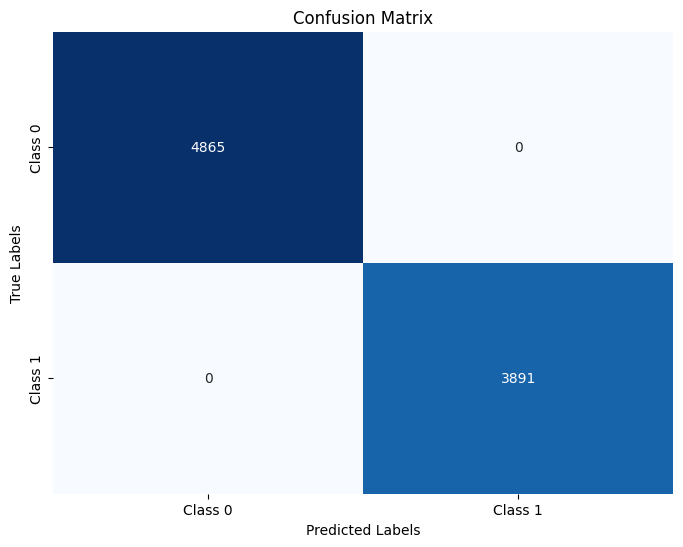

In [84]:
cm1 = confusion_matrix(y_test, y_pred_lstm_raw_labels)

print("Confusion matrix Without autoencoder:")
# Plot the confusion matrix using seaborn heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(cm1, annot=True, fmt="d", cmap="Blues", cbar=False, 
            xticklabels=['Class 0', 'Class 1'], yticklabels=['Class 0', 'Class 1'])

plt.title("Confusion Matrix")
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.show()

Performance without Autoencoder :
Classification report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      4865
           1       1.00      1.00      1.00      3891

    accuracy                           1.00      8756
   macro avg       1.00      1.00      1.00      8756
weighted avg       1.00      1.00      1.00      8756

Accuracy: 1.0
Precision : 1.0
Recall : 1.0
F1-Score : 1.0
F2-Score : 1.0
Cohen's Kappa Score : 1.0
Matthews Correlation Coefficient (MCC) : 1.0
Specificity : 1.0
G-means : 1.0


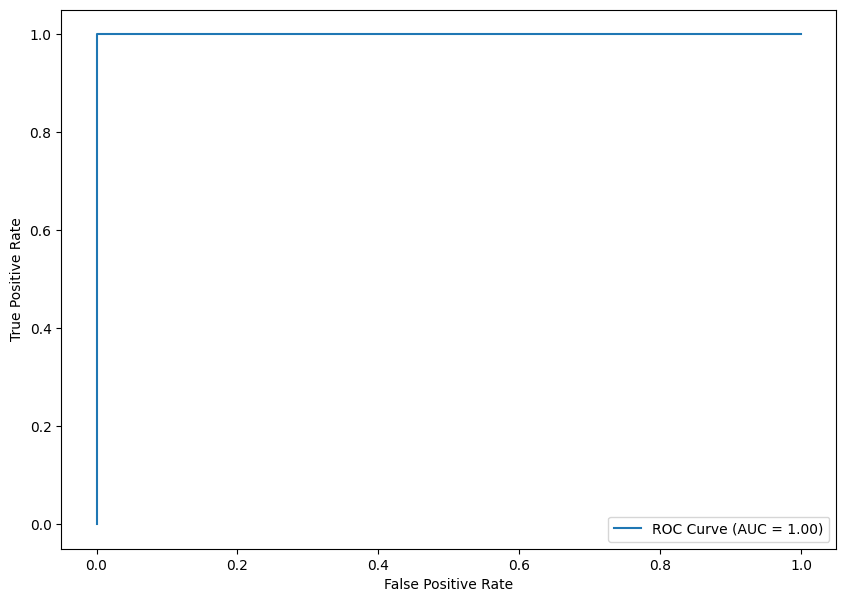

In [85]:
print("Performance without Autoencoder :")

print("Classification report:")
print(classification_report(y_test, y_pred_lstm_raw_labels))

print("Accuracy:", accuracy_score(y_test, y_pred_lstm_raw_labels))
print("Precision :", precision_score(y_test, y_pred_lstm_raw_labels))
print("Recall :", recall_score(y_test, y_pred_lstm_raw_labels))
print("F1-Score :", f1_score(y_test, y_pred_lstm_raw_labels))

# Compute F2-Score
f2 = fbeta_score(y_test, y_pred_lstm_raw_labels, beta=2)
print("F2-Score :", f2)
print("Cohen's Kappa Score :", cohen_kappa_score(y_test, y_pred_lstm_raw_labels))
print("Matthews Correlation Coefficient (MCC) :", matthews_corrcoef(y_test, y_pred_lstm_raw_labels))
# Calcul de la matrice de confusion
tn, fp, fn, tp = confusion_matrix(y_test, y_pred_lstm_raw_labels).ravel()

# Calcul de la sensibilité (rappel)
sensitivity = tp / (tp + fn)

# Calcul de la spécificité
specificity = tn / (tn + fp)
print(f"Specificity : {specificity}")
# Calcul du G-means
g_means = np.sqrt(sensitivity * specificity)
print(f"G-means : {g_means}")
# Calculer l'AUC
#y_proba_trans = y_pred[:, 1]  # Extract probability of class 1
auc_score = roc_auc_score(y_test, y_pred_lstm_raw_labels)

# Calculer les valeurs FPR et TPR pour la courbe ROC
fpr, tpr, _ = roc_curve(y_test, y_pred_lstm_raw_labels)

# ROC Curve Data
plt.figure(figsize=(10, 7))

# Tracer la courbe ROC
plt.plot(fpr, tpr, label="ROC Curve (AUC = {:.2f})".format(auc_score))
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.show()

Confusion matrix With autoencoder:


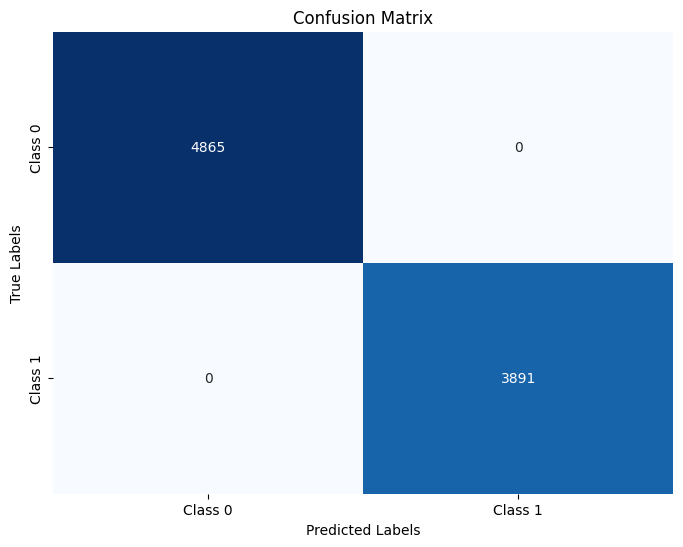

In [86]:
cm = confusion_matrix(y_test, y_pred_lstm_ae_labels)

print("Confusion matrix With autoencoder:")
# Plot the confusion matrix using seaborn heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(cm1, annot=True, fmt="d", cmap="Blues", cbar=False, 
            xticklabels=['Class 0', 'Class 1'], yticklabels=['Class 0', 'Class 1'])

plt.title("Confusion Matrix")
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.show()

Performance with Autoencoder :
Classification report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      4865
           1       1.00      1.00      1.00      3891

    accuracy                           1.00      8756
   macro avg       1.00      1.00      1.00      8756
weighted avg       1.00      1.00      1.00      8756

Accuracy: 1.0
Precision : 1.0
Recall : 1.0
F1-Score : 1.0
F2-Score : 1.0
Cohen's Kappa Score : 1.0
Matthews Correlation Coefficient (MCC) : 1.0
Specificity : 1.0
G-means : 1.0


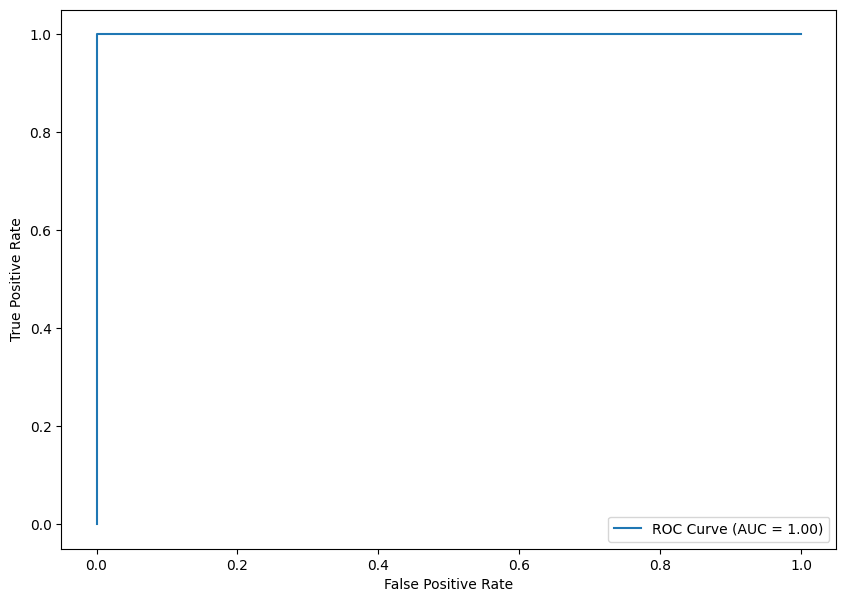

In [87]:
print("Performance with Autoencoder :")

print("Classification report:")
print(classification_report(y_test, y_pred_lstm_ae_labels))
print("Accuracy:", accuracy_score(y_test, y_pred_lstm_ae_labels))
print("Precision :", precision_score(y_test, y_pred_lstm_ae_labels))
print("Recall :", recall_score(y_test, y_pred_lstm_ae_labels))
print("F1-Score :", f1_score(y_test, y_pred_lstm_ae_labels))

# Compute F2-Score
f2 = fbeta_score(y_test, y_pred_lstm_ae_labels, beta=2)
print("F2-Score :", f2)
print("Cohen's Kappa Score :", cohen_kappa_score(y_test, y_pred_lstm_ae_labels))
print("Matthews Correlation Coefficient (MCC) :", matthews_corrcoef(y_test, y_pred_lstm_ae_labels))
# Calcul de la matrice de confusion
tn, fp, fn, tp = confusion_matrix(y_test, y_pred_lstm_ae_labels).ravel()

# Calcul de la sensibilité (rappel)
sensitivity = tp / (tp + fn)

# Calcul de la spécificité
specificity = tn / (tn + fp)
print(f"Specificity : {specificity}")
# Calcul du G-means
g_means = np.sqrt(sensitivity * specificity)
print(f"G-means : {g_means}")
# Calculer l'AUC
#y_proba_trans = y_pred[:, 1]  # Extract probability of class 1
auc_score = roc_auc_score(y_test, y_pred_lstm_ae_labels)

# Calculer les valeurs FPR et TPR pour la courbe ROC
fpr, tpr, _ = roc_curve(y_test, y_pred_lstm_ae_labels)

# ROC Curve Data
plt.figure(figsize=(10, 7))

# Tracer la courbe ROC
plt.plot(fpr, tpr, label="ROC Curve (AUC = {:.2f})".format(auc_score))
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.show()

In [89]:
import pickle
from tensorflow.keras.models import load_model

# Sauvegarde du modèle avec pickle
with open('fraud_model.pkl', 'wb') as f:
    pickle.dump(lstm_model, f)

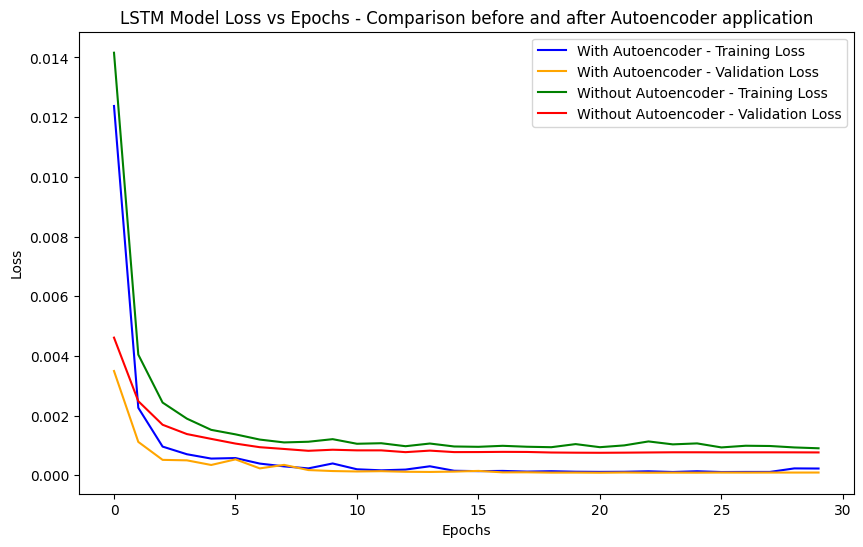

In [88]:
# Extract loss values
train_loss = history.history['loss']  # Training loss for each epoch
val_loss = history.history['val_loss']  # Validation loss for each epoch (if validation data is provided)

train_loss2 = history_raw.history['loss']
val_loss2 = history_raw.history['val_loss']

# Plotting the loss curves for both models
plt.figure(figsize=(10, 6))

# Plot for Model 1
plt.plot(train_loss, label='With Autoencoder - Training Loss', color='blue')
plt.plot(val_loss, label='With Autoencoder - Validation Loss', color='orange')

# Plot for Model 2
plt.plot(train_loss2, label='Without Autoencoder - Training Loss', color='green')
plt.plot(val_loss2, label='Without Autoencoder - Validation Loss', color='red')

# Adding labels and title
plt.title('LSTM Model Loss vs Epochs - Comparison before and after Autoencoder application')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

# Show the plot
plt.show()

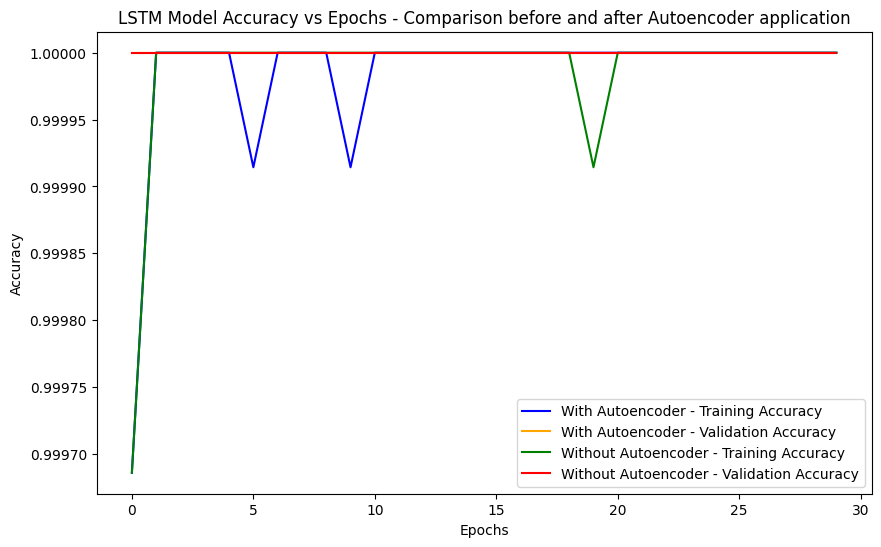

In [90]:
train_acc1 = history.history['accuracy']
val_acc1 = history.history['val_accuracy']

train_acc2 = history_raw.history['accuracy']
val_acc2 = history_raw.history['val_accuracy']

# Plotting accuracy for all models
plt.figure(figsize=(10, 6))
plt.plot(train_acc1, label='With Autoencoder - Training Accuracy', color='blue')
plt.plot(val_acc1, label='With Autoencoder - Validation Accuracy', color='orange')

plt.plot(train_acc2, label='Without Autoencoder - Training Accuracy', color='green')
plt.plot(val_acc2, label='Without Autoencoder - Validation Accuracy', color='red')


plt.title('LSTM Model Accuracy vs Epochs - Comparison before and after Autoencoder application')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

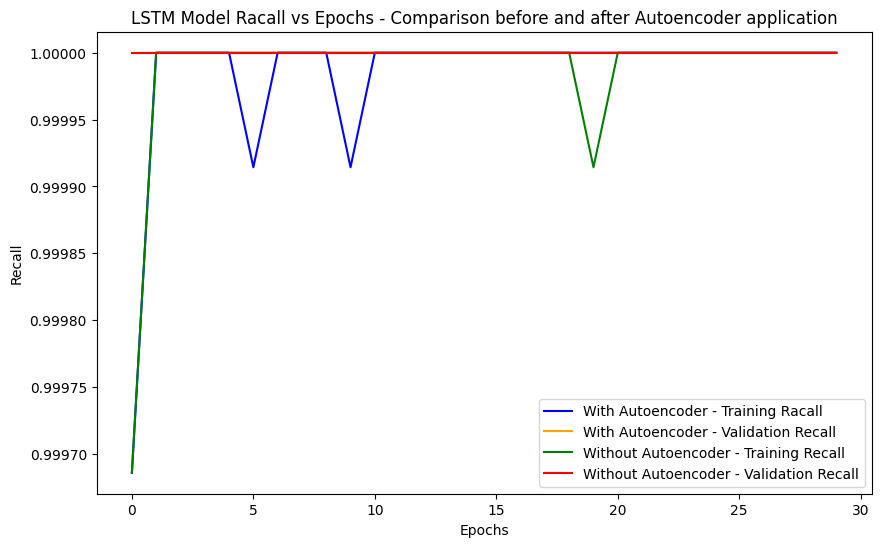

In [91]:
train_recall1 = history.history['recall']
val_recall1 = history.history['val_recall']

train_recall2 = history_raw.history['recall_1']
val_recall2 = history_raw.history['val_recall_1']

# Plotting accuracy for all models
plt.figure(figsize=(10, 6))
plt.plot(train_recall1, label='With Autoencoder - Training Racall', color='blue')
plt.plot(val_recall1, label='With Autoencoder - Validation Recall', color='orange')

plt.plot(train_recall2, label='Without Autoencoder - Training Recall', color='green')
plt.plot(val_recall2, label='Without Autoencoder - Validation Recall', color='red')


plt.title('LSTM Model Racall vs Epochs - Comparison before and after Autoencoder application')
plt.xlabel('Epochs')
plt.ylabel('Recall')
plt.legend()
plt.show()

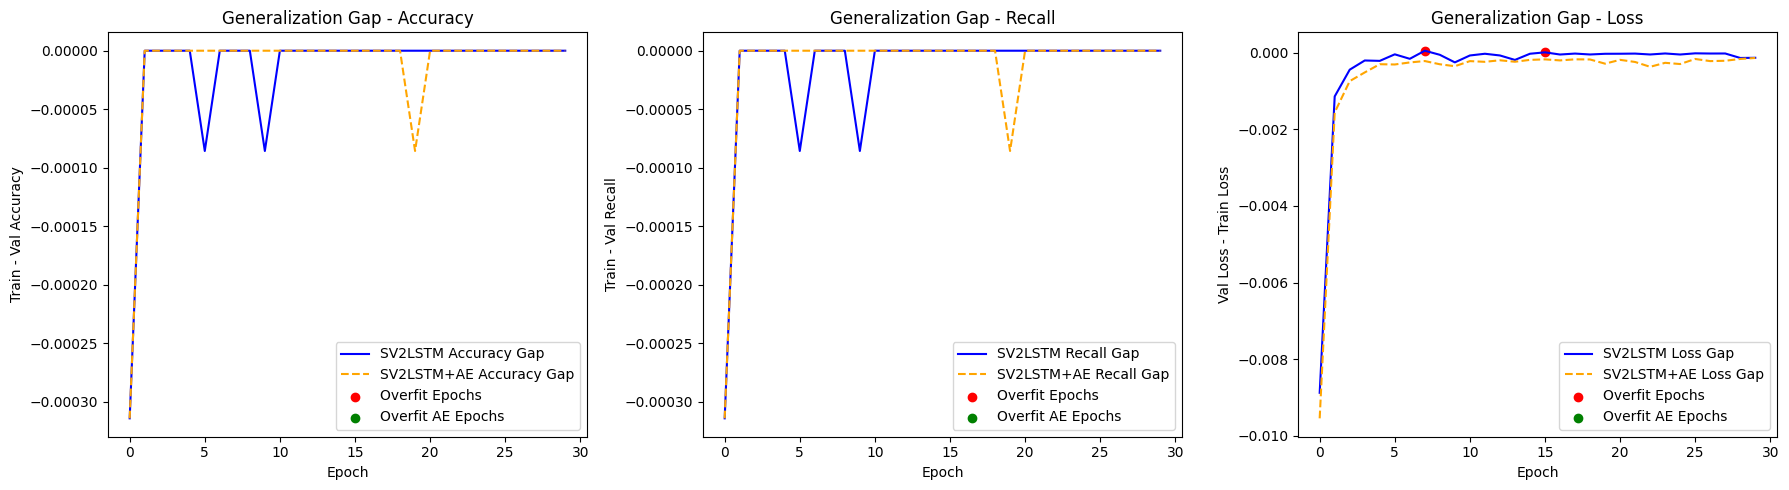

First overfitting epoch (Loss, SV2LSTM): 8


In [92]:
import numpy as np
import matplotlib.pyplot as plt

# Accuracy and Recall over epochs
train_acc = history.history['accuracy']          # training accuracy per epoch
val_acc   = history.history['val_accuracy']      # validation accuracy per epoch

train_acc_raw = history_raw.history['accuracy']          # training accuracy per epoch
val_acc_raw   = history_raw.history['val_accuracy']      # validation accuracy per epoch


train_recall = history.history['recall']
val_recall = history.history['val_recall']

train_recall_raw = history_raw.history['recall_1']
val_recall_raw = history_raw.history['val_recall_1']


# Convert to numpy arrays
train_acc = np.array(train_acc)
val_acc   = np.array(val_acc)
train_acc_raw = np.array(train_acc_raw)
val_acc_raw   = np.array(val_acc_raw)

train_recall = np.array(train_recall)
val_recall   = np.array(val_recall)
train_recall_raw = np.array(train_recall_raw)
val_recall_raw   = np.array(val_recall_raw)

train_loss = np.array(history.history['loss'])
val_loss   = np.array(history.history['val_loss'])
train_loss2 = np.array(history_raw.history['loss'])
val_loss2   = np.array(history_raw.history['val_loss'])

# Compute generalization gaps
acc_gap = train_acc - val_acc
acc_gap_raw = train_acc_raw - val_acc_raw

recall_gap = train_recall - val_recall
recall_gap_raw = train_recall_raw - val_recall_raw

loss_gap = val_loss - train_loss
loss_gap_raw = val_loss2 - train_loss2

# Identify overfitting epochs
overfit_loss_epochs = np.where(loss_gap > 0)[0]
overfit_loss_epochs_raw = np.where(loss_gap_raw > 0)[0]

overfit_acc_epochs = np.where(acc_gap > 0)[0]
overfit_acc_epochs_raw = np.where(acc_gap_raw > 0)[0]

overfit_recall_epochs = np.where(recall_gap > 0)[0]
overfit_recall_epochs_raw = np.where(recall_gap_raw > 0)[0]

# Plotting
plt.figure(figsize=(18,5))

# Accuracy gap
plt.subplot(1,3,1)
plt.plot(acc_gap, label='SV2LSTM Accuracy Gap', color='blue', linestyle='-')
plt.plot(acc_gap_raw, label='SV2LSTM+AE Accuracy Gap', color='orange', linestyle='--')
plt.scatter(overfit_acc_epochs, acc_gap[overfit_acc_epochs], color='red', label='Overfit Epochs')
plt.scatter(overfit_acc_epochs_raw, acc_gap_raw[overfit_acc_epochs_raw], color='green', label='Overfit AE Epochs')
plt.title('Generalization Gap - Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Train - Val Accuracy')
plt.grid(False)
plt.legend()

# Recall gap
plt.subplot(1,3,2)
plt.plot(recall_gap, label='SV2LSTM Recall Gap', color='blue', linestyle='-')
plt.plot(recall_gap_raw, label='SV2LSTM+AE Recall Gap', color='orange', linestyle='--')
plt.scatter(overfit_recall_epochs, recall_gap[overfit_recall_epochs], color='red', label='Overfit Epochs')
plt.scatter(overfit_recall_epochs_raw, recall_gap_raw[overfit_recall_epochs_raw], color='green', label='Overfit AE Epochs')
plt.title('Generalization Gap - Recall')
plt.xlabel('Epoch')
plt.ylabel('Train - Val Recall')
plt.grid(False)
plt.legend()

# Loss gap
plt.subplot(1,3,3)
plt.plot(loss_gap, label='SV2LSTM Loss Gap', color='blue')
plt.plot(loss_gap_raw, label='SV2LSTM+AE Loss Gap', color='orange', linestyle='--')
plt.scatter(overfit_loss_epochs, loss_gap[overfit_loss_epochs], color='red', label='Overfit Epochs')
plt.scatter(overfit_loss_epochs_raw, loss_gap_raw[overfit_loss_epochs_raw], color='green', label='Overfit AE Epochs')
plt.title('Generalization Gap - Loss')
plt.xlabel('Epoch')
plt.ylabel('Val Loss - Train Loss')
plt.grid(False)
plt.legend()

plt.tight_layout()
# Save the figure
plt.savefig("SV2LSTM_IEEE_CIS_SMOTE_generalization_gap.png", dpi=300)  # high-resolution PNG
plt.show()

# Optional: print first overfitting epoch for each metric
if len(overfit_loss_epochs) > 0:
    print(f"First overfitting epoch (Loss, SV2LSTM): {overfit_loss_epochs[0]+1}")
if len(overfit_loss_epochs_raw) > 0:
    print(f"First overfitting epoch (Loss, SV2LSTM+AE): {overfit_loss_epochs_raw[0]+1}")
if len(overfit_acc_epochs) > 0:
    print(f"First overfitting epoch (Accuracy, SV2LSTM): {overfit_acc_epochs[0]+1}")
if len(overfit_acc_epochs_raw) > 0:
    print(f"First overfitting epoch (Accuracy, SV2LSTM+AE): {overfit_acc_epochs_raw[0]+1}")
if len(overfit_recall_epochs) > 0:
    print(f"First overfitting epoch (Recall, SV2LSTM): {overfit_recall_epochs[0]+1}")
if len(overfit_recall_epochs_raw) > 0:
    print(f"First overfitting epoch (Recall, SV2LSTM+AE): {overfit_recall_epochs_raw[0]+1}")
